# Face Recognition on LFW using CNN
This notebook trains a face-identification model on the **Labeled Faces in the Wild (LFW)** dataset

---
## 1. Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, top_k_accuracy_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.20.0
GPU Available: []


---
## 2. Load the Labeled Faces in the Wild (LFW) Dataset


In [2]:
print("Fetching LFW dataset (this may take a while on first run)...")
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.7, color=True)

n_samples, h, w, c = lfw_people.images.shape
X = lfw_people.data
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print("\n--- Dataset Summary ---")
print(f"Total Samples:     {n_samples}")
print(f"Image Dimensions:  {h} x {w} x {c}")
print(f"Number of Classes: {n_classes}")
print("Classes:", list(target_names))
print(f"\nRaw pixel value range: [{lfw_people.images.min():.3f}, {lfw_people.images.max():.3f}]  "
      f"(already normalized by scikit-learn — do NOT divide by 255 again)")


Fetching LFW dataset (this may take a while on first run)...

--- Dataset Summary ---
Total Samples:     1288
Image Dimensions:  87 x 65 x 3
Number of Classes: 7
Classes: [np.str_('Ariel Sharon'), np.str_('Colin Powell'), np.str_('Donald Rumsfeld'), np.str_('George W Bush'), np.str_('Gerhard Schroeder'), np.str_('Hugo Chavez'), np.str_('Tony Blair')]

Raw pixel value range: [0.000, 1.000]  (already normalized by scikit-learn — do NOT divide by 255 again)


---
## 3. Exploratory Data Analysis (EDA) & Visualization

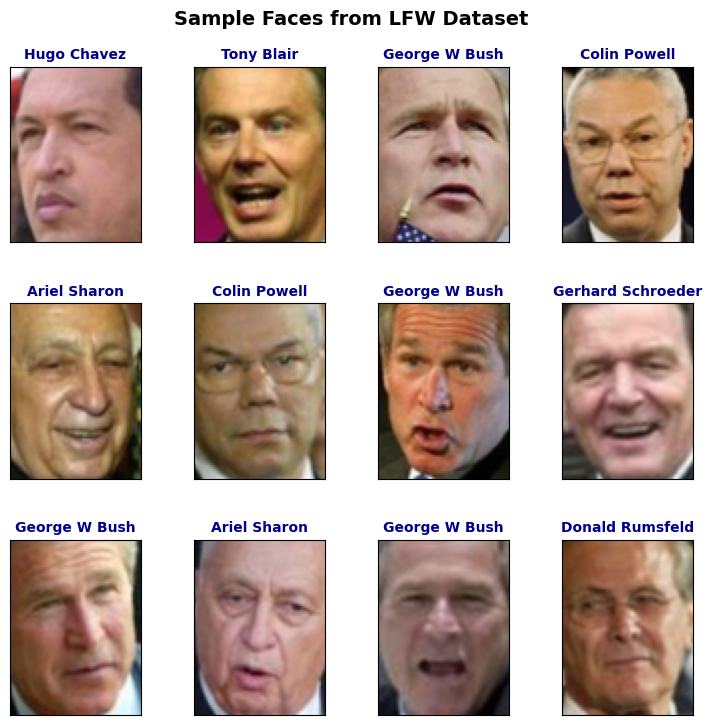

C:\Users\tarun\AppData\Local\Temp\ipykernel_8744\2329237316.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[target_names[i] for i in order], y=[counts[i] for i in order], palette='viridis')


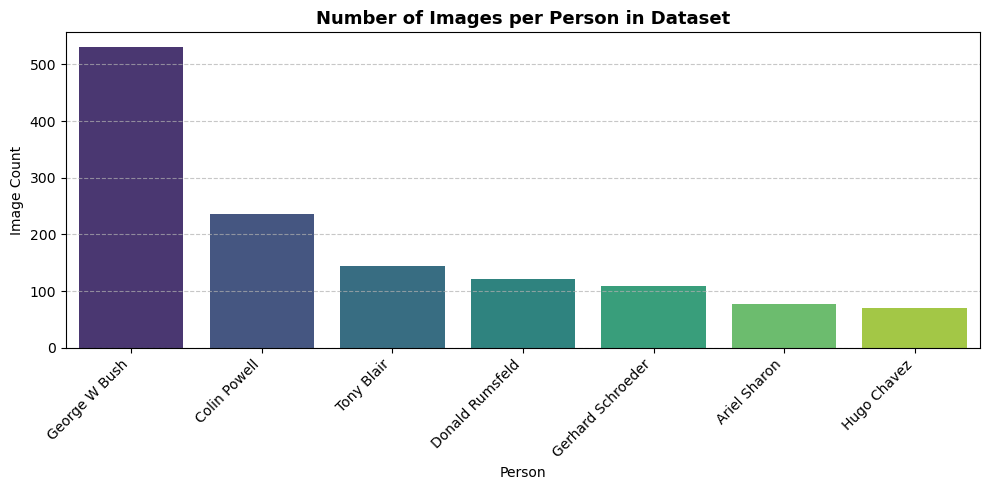

Class imbalance ratio (max/min class count): 7.46x


In [3]:
def plot_gallery(images, titles, n_row=3, n_col=4):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i])
        plt.title(titles[i], size=10, color='darkblue', fontweight='bold')
        plt.xticks(())
        plt.yticks(())
    plt.suptitle("Sample Faces from LFW Dataset", fontsize=14, fontweight='bold')
    plt.show()

plot_gallery(lfw_people.images, [target_names[i] for i in y])

# Class distribution (LFW is naturally imbalanced -- this is why we use class weights later)
plt.figure(figsize=(10, 5))
counts = [np.sum(y == i) for i in range(n_classes)]
order = np.argsort(counts)[::-1]
sns.barplot(x=[target_names[i] for i in order], y=[counts[i] for i in order], palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("Number of Images per Person in Dataset", fontsize=13, fontweight='bold')
plt.xlabel("Person")
plt.ylabel("Image Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

imbalance_ratio = max(counts) / min(counts)
print(f"Class imbalance ratio (max/min class count): {imbalance_ratio:.2f}x")


---
## 4. Data Preprocessing & Train / Validation / Test Split


In [4]:
X_images = lfw_people.images.astype("float32")  # already in [0, 1], keep as-is

# First split off the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_images, y, test_size=0.15, random_state=SEED, stratify=y
)

# Then split the remainder into train (70% overall) / validation (15% overall)
val_fraction_of_temp = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_fraction_of_temp, random_state=SEED, stratify=y_temp
)

print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Testing set shape:    {X_test.shape}")

# One-hot targets (needed for label-smoothed CategoricalCrossentropy)
y_train_oh = to_categorical(y_train, n_classes)
y_val_oh = to_categorical(y_val, n_classes)
y_test_oh = to_categorical(y_test, n_classes)

# Class weights (computed on the training split only, using integer labels)
class_weight_values = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weight_values))
print("\nClass weights:")
for idx, wgt in class_weight_dict.items():
    print(f"  {target_names[idx]:25s}: {wgt:.3f}")


Training set shape:   (900, 87, 65, 3)
Validation set shape: (194, 87, 65, 3)
Testing set shape:    (194, 87, 65, 3)

Class weights:
  Ariel Sharon             : 2.381
  Colin Powell             : 0.779
  Donald Rumsfeld          : 1.513
  George W Bush            : 0.347
  Gerhard Schroeder        : 1.670
  Hugo Chavez              : 2.624
  Tony Blair               : 1.286


## 5. Transfer-Learning Model: MobileNetV2 Backbone + Custom Head

In [5]:
IMG_SIZE = 160

def build_transfer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)

    # Train-time-only data augmentation
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomZoom(0.08)(x)
    x = layers.RandomContrast(0.1)(x)

    # Native [0, 1] -> MobileNetV2's expected [-1, 1] range
    x = layers.Rescaling(2.0, offset=-1.0)(x)

    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Stage 1: frozen backbone

    x = base_model(x, training=False)  # keep BatchNorm stats frozen even after later unfreezing
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="lfw_mobilenetv2")
    return model, base_model

input_shape = (h, w, c)
model, base_model = build_transfer_model(input_shape, n_classes)
model.summary()


Model: "lfw_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 87, 65, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resizing (Resizing)                  │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_flip (RandomFlip)             │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_contrast (RandomContrast)     │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │           1,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,588,743 (9.88 MB)

 Trainable params: 330,247 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

---
## 6. Stage 1 — Train the Classification Head (Frozen Backbone)

Label smoothing (`label_smoothing=0.1`) softens the target distribution slightly, which discourages
the model from becoming overconfident on any single training example — one of the main causes of
sharp, wrong high-confidence predictions.

In [6]:
os.makedirs('artifacts', exist_ok=True)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

stage1_early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)
stage1_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
)
stage1_checkpoint = callbacks.ModelCheckpoint(
    'artifacts/best_lfw_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0
)

STAGE1_EPOCHS = 25
BATCH_SIZE = 32

history_stage1 = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=STAGE1_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[stage1_early_stop, stage1_reduce_lr, stage1_checkpoint],
    verbose=1
)


Epoch 1/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 590ms/step - accuracy: 0.2461 - loss: 2.6650 - val_accuracy: 0.5464 - val_loss: 1.6835 - learning_rate: 0.0010
Epoch 2/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 564ms/step - accuracy: 0.5473 - loss: 1.6065 - val_accuracy: 0.7938 - val_loss: 1.0963 - learning_rate: 0.0010
Epoch 3/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 539ms/step - accuracy: 0.5886 - loss: 1.3803 - val_accuracy: 0.7835 - val_loss: 1.0395 - learning_rate: 0.0010
Epoch 4/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 515ms/step - accuracy: 0.6212 - loss: 1.3463 - val_accuracy: 0.8144 - val_loss: 1.0052 - learning_rate: 0.0010
Epoch 5/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 541ms/step - accuracy: 0.6999 - loss: 1.1861 - val_accuracy: 0.8041 - val_loss: 0.9372 - learning_rate: 0.0010
Epoch 6/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 565ms/step - accuracy: 0.7282 - loss: 1.0965 - val_accuracy: 0.8041 - val_loss: 0.9276 - learning_rate: 0.0010
Epoch 7/25
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 544ms/step - accuracy: 0.7281 - loss: 1.

## 7. Stage 2 — Fine-Tune the Backbone

In [7]:
base_model.trainable = True

fine_tune_at = max(0, len(base_model.layers) - 40)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Fine-tuning the top {trainable_count} / {len(base_model.layers)} backbone layers.")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

stage2_early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)
stage2_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1
)
stage2_checkpoint = callbacks.ModelCheckpoint(
    'artifacts/best_lfw_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0
)

STAGE2_EPOCHS = 40
initial_epoch = len(history_stage1.history['loss'])

history_stage2 = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=initial_epoch + STAGE2_EPOCHS,
    initial_epoch=initial_epoch,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[stage2_early_stop, stage2_reduce_lr, stage2_checkpoint],
    verbose=1
)


Fine-tuning the top 40 / 154 backbone layers.
Epoch 26/65
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 771ms/step - accuracy: 0.5503 - loss: 1.7609 - val_accuracy: 0.8660 - val_loss: 0.8449 - learning_rate: 1.0000e-05
Epoch 27/65
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 653ms/step - accuracy: 0.5701 - loss: 1.8339 - val_accuracy: 0.8402 - val_loss: 0.8812 - learning_rate: 1.0000e-05
Epoch 28/65
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 678ms/step - accuracy: 0.5978 - loss: 1.5111 - val_accuracy: 0.8454 - val_loss: 0.9141 - learning_rate: 1.0000e-05
Epoch 29/65
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 701ms/step - accuracy: 0.6177 - loss: 1.5728 - val_accuracy: 0.8351 - val_loss: 0.9640 - learning_rate: 1.0000e-05
Epoch 30/65
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 673ms/step - accuracy: 0.6658 - loss: 1.3682 - val_accuracy: 0.8196 - val_loss: 1.0182 - learning_rate: 1.0000e-05
Epoch 31/65
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.6818 - loss: 1.3122
Epoch 31: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.


---
## 8. Combined Training History: Accuracy, Loss & Learning-Rate Curves

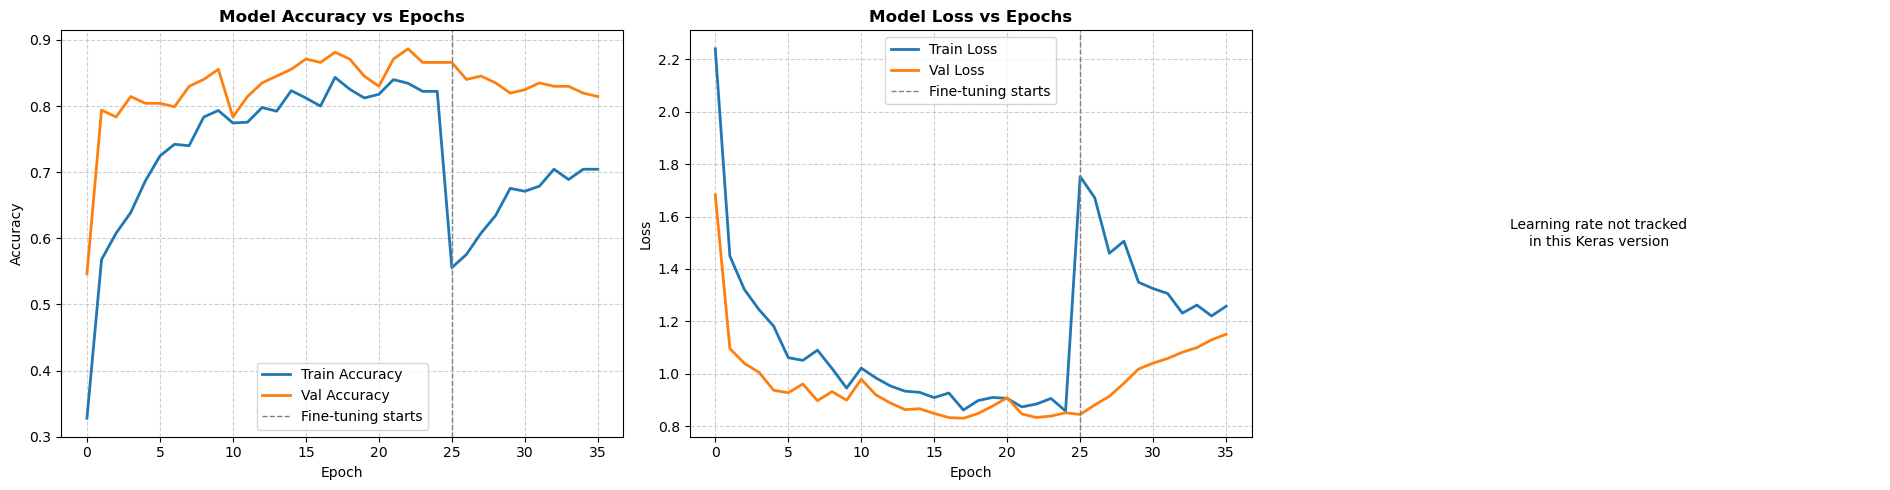

Training ran for 36 total epochs (Stage 1: 25, Stage 2: 11).
Best val_accuracy at epoch 23: 88.66%


In [8]:
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = list(h1.history[key]) + list(h2.history.get(key, []))
    return merged

hist = merge_histories(history_stage1, history_stage2)
fine_tune_start_epoch = len(history_stage1.history['loss'])

fig, ax = plt.subplots(1, 3, figsize=(19, 5))

ax[0].plot(hist['accuracy'], label='Train Accuracy', color='#1f77b4', linewidth=2)
ax[0].plot(hist['val_accuracy'], label='Val Accuracy', color='#ff7f0e', linewidth=2)
ax[0].axvline(fine_tune_start_epoch, color='gray', linestyle='--', linewidth=1, label='Fine-tuning starts')
ax[0].set_title('Model Accuracy vs Epochs', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].plot(hist['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
ax[1].plot(hist['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
ax[1].axvline(fine_tune_start_epoch, color='gray', linestyle='--', linewidth=1, label='Fine-tuning starts')
ax[1].set_title('Model Loss vs Epochs', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

if 'lr' in hist:
    ax[2].plot(hist['lr'], color='#2ca02c', linewidth=2)
    ax[2].axvline(fine_tune_start_epoch, color='gray', linestyle='--', linewidth=1)
    ax[2].set_yscale('log')
    ax[2].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    ax[2].set_xlabel('Epoch')
    ax[2].set_ylabel('Learning Rate (log scale)')
    ax[2].grid(True, linestyle='--', alpha=0.6)
else:
    ax[2].axis('off')
    ax[2].text(0.5, 0.5, 'Learning rate not tracked\nin this Keras version', ha='center', va='center')

plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(hist['val_accuracy'])) + 1
print(f"Training ran for {len(hist['loss'])} total epochs "
      f"(Stage 1: {fine_tune_start_epoch}, Stage 2: {len(hist['loss']) - fine_tune_start_epoch}).")
print(f"Best val_accuracy at epoch {best_epoch}: {max(hist['val_accuracy']) * 100:.2f}%")


---
## 9. Final Test Set Evaluation & Performance Metrics

This is the **first and only time** the test set is used.

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

top1 = top_k_accuracy_score(y_test, y_pred_probs, k=1, labels=np.arange(n_classes))
top3 = top_k_accuracy_score(y_test, y_pred_probs, k=3, labels=np.arange(n_classes))
print(f"Top-1 Accuracy: {top1 * 100:.2f}%")
print(f"Top-3 Accuracy: {top3 * 100:.2f}%")

mean_confidence_correct = y_pred_probs[np.arange(len(y_pred)), y_pred][y_pred == y_test].mean() * 100
mean_confidence_wrong = (
    y_pred_probs[np.arange(len(y_pred)), y_pred][y_pred != y_test].mean() * 100
    if np.any(y_pred != y_test) else float('nan')
)
print(f"Mean confidence on CORRECT predictions: {mean_confidence_correct:.2f}%")
print(f"Mean confidence on WRONG predictions:   {mean_confidence_wrong:.2f}%")

print("\n--- Classification Report ---")
report_str = classification_report(y_test, y_pred, target_names=target_names)
print(report_str)
report_dict = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)


Test Loss:     0.8863
Test Accuracy: 87.11%
Top-1 Accuracy: 87.11%
Top-3 Accuracy: 96.91%
Mean confidence on CORRECT predictions: 82.53%
Mean confidence on WRONG predictions:   57.91%

--- Classification Report ---
                   precision    recall  f1-score   support

     Ariel Sharon       0.92      0.92      0.92        12
     Colin Powell       0.94      0.83      0.88        35
  Donald Rumsfeld       0.90      1.00      0.95        18
    George W Bush       0.93      0.93      0.93        80
Gerhard Schroeder       0.58      0.69      0.63        16
      Hugo Chavez       1.00      0.64      0.78        11
       Tony Blair       0.76      0.86      0.81        22

         accuracy                           0.87       194
        macro avg       0.86      0.84      0.84       194
     weighted avg       0.88      0.87      0.87       194



### 9.1 Per-Class Precision / Recall / F1

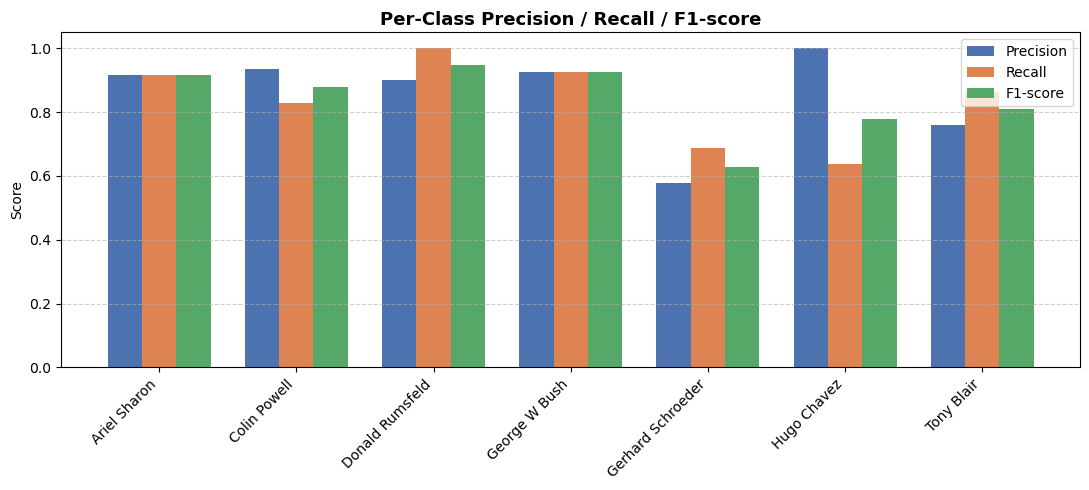

In [10]:
metrics_df_names = list(target_names)
precision = [report_dict[name]['precision'] for name in metrics_df_names]
recall = [report_dict[name]['recall'] for name in metrics_df_names]
f1 = [report_dict[name]['f1-score'] for name in metrics_df_names]

x = np.arange(len(metrics_df_names))
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, precision, width, label='Precision', color='#4c72b0')
plt.bar(x, recall, width, label='Recall', color='#dd8452')
plt.bar(x + width, f1, width, label='F1-score', color='#55a868')
plt.xticks(x, metrics_df_names, rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Per-Class Precision / Recall / F1-score', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 9.2 Confusion Matrix (raw counts and row-normalized)

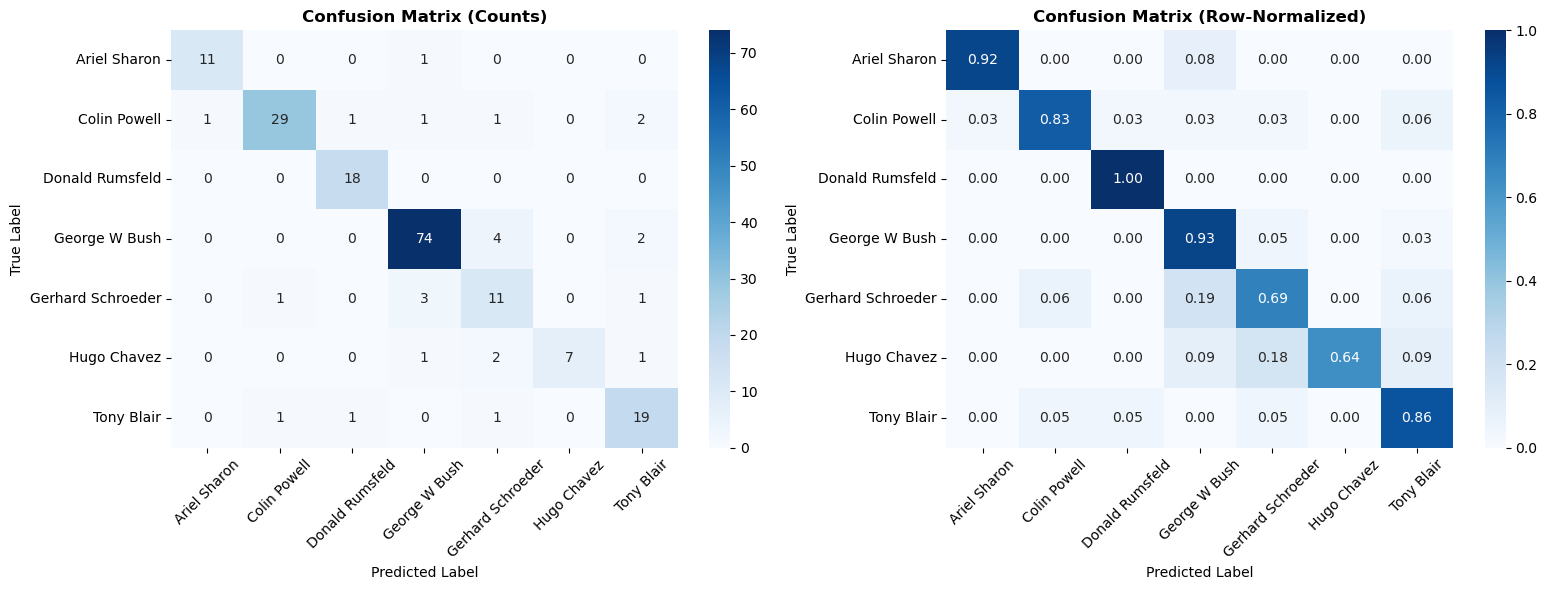

In [11]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax[0])
ax[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')
ax[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax[1])
ax[1].set_title('Confusion Matrix (Row-Normalized)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 9.3 ROC Curves (One-vs-Rest, per class + macro average)

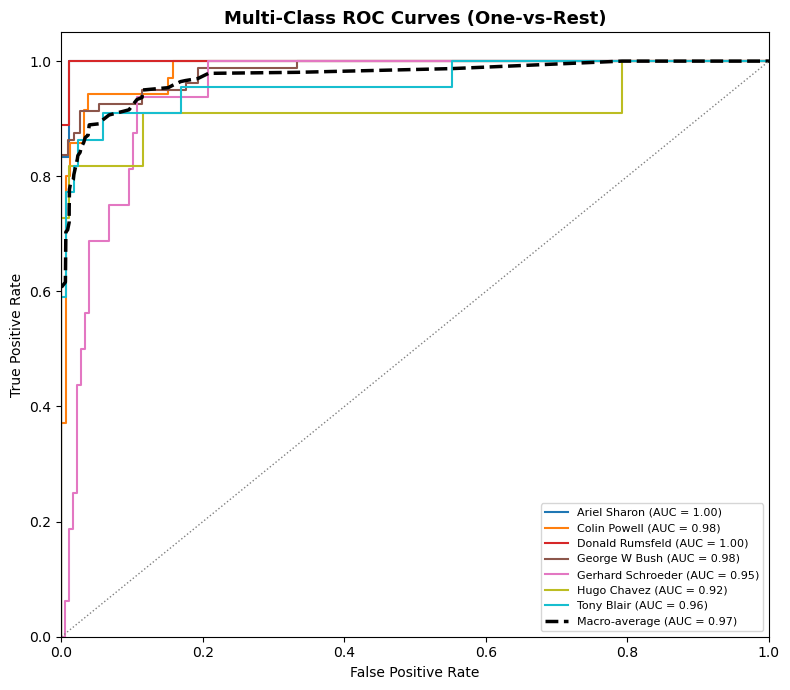

In [12]:
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 7))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, linewidth=1.5,
             label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(fpr["macro"], tpr["macro"], color='black', linestyle='--', linewidth=2.5,
         label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


---
## 10. Visualizing Face Recognition Predictions

Correct predictions are highlighted with green titles, incorrect ones in red, each annotated with model confidence.

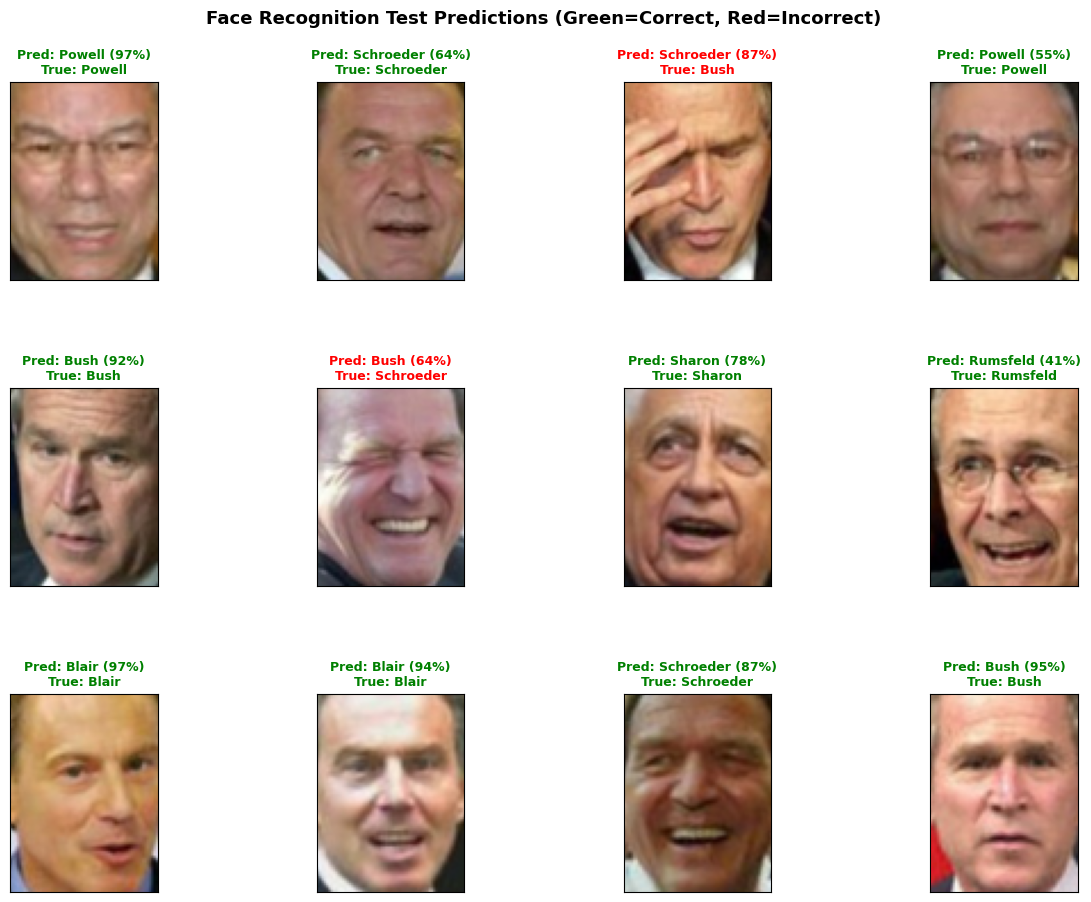

In [13]:
def pred_title(y_pred, y_pred_probs, y_test, target_names, i):
    pred_idx = y_pred[i]
    pred_name = target_names[pred_idx].split()[-1]
    true_name = target_names[y_test[i]].split()[-1]
    confidence = y_pred_probs[i, pred_idx] * 100
    is_correct = (pred_idx == y_test[i])
    text = f"Pred: {pred_name} ({confidence:.0f}%)\nTrue: {true_name}"
    color = 'green' if is_correct else 'red'
    return text, color

n_show = 12
plt.figure(figsize=(12, 9))
plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.55)
for i in range(n_show):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i])
    text, color = pred_title(y_pred, y_pred_probs, y_test, target_names, i)
    plt.title(text, size=9, color=color, fontweight='bold')
    plt.xticks(())
    plt.yticks(())
plt.suptitle("Face Recognition Test Predictions (Green=Correct, Red=Incorrect)", fontsize=13, fontweight='bold')
plt.show()


---
## 11. Reusable Single-Face Prediction Function

Takes a raw face image array (values in `[0, 1]` or `[0, 255]`, the function normalizes automatically)
and returns the predicted identity, confidence, and top-3 candidates.

In [14]:
def recognize_face(image_array, model, target_names, h, w, c, top_k=3):
    # Recognize a face from a 2D/3D numpy image array. Handles both [0,1] and [0,255] inputs.
    img = np.asarray(image_array, dtype='float32').reshape(1, h, w, c)
    if img.max() > 1.0:
        img = img / 255.0

    probabilities = model.predict(img, verbose=0)[0]
    top_k_idx = np.argsort(probabilities)[::-1][:top_k]
    top_k_results = [(target_names[i], float(probabilities[i] * 100)) for i in top_k_idx]

    predicted_class_idx = top_k_idx[0]
    predicted_name = target_names[predicted_class_idx]
    confidence = float(probabilities[predicted_class_idx] * 100)

    return predicted_name, confidence, top_k_results


## 12. 🎯 Final Demo — Predict the Identity of a Test-Set Image

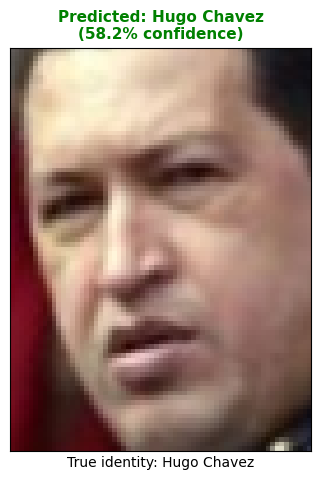

Test image index:     183
True identity:        Hugo Chavez
Predicted identity:   Hugo Chavez
Confidence:           58.24%
Correct prediction:   YES

Top-3 candidates:
  1. Hugo Chavez               58.24%  <-- true identity
  2. George W Bush             21.69%
  3. Tony Blair                 9.18%


In [15]:
# Pick a random test-set image (change the seed/index to try a different photo)
rng = np.random.default_rng(7)
sample_idx = rng.integers(0, len(X_test))

sample_img = X_test[sample_idx]
true_label = target_names[y_test[sample_idx]]

predicted_name, confidence, top3 = recognize_face(sample_img, model, target_names, h, w, c)
is_correct = predicted_name == true_label

plt.figure(figsize=(4, 5))
plt.imshow(sample_img)
plt.xticks(())
plt.yticks(())
title_color = 'green' if is_correct else 'red'
plt.title(f"Predicted: {predicted_name}\n({confidence:.1f}% confidence)",
          color=title_color, fontsize=11, fontweight='bold')
plt.suptitle(f"True identity: {true_label}", fontsize=10, y=0.02)
plt.tight_layout()
plt.show()

print(f"Test image index:     {sample_idx}")
print(f"True identity:        {true_label}")
print(f"Predicted identity:   {predicted_name}")
print(f"Confidence:           {confidence:.2f}%")
print(f"Correct prediction:   {'YES' if is_correct else 'NO'}")
print("\nTop-3 candidates:")
for rank, (cand_name, cand_conf) in enumerate(top3, start=1):
    marker = "  <-- true identity" if cand_name == true_label else ""
    print(f"  {rank}. {cand_name:25s} {cand_conf:5.2f}%{marker}")



## 13. Saving the Trained Model



In [16]:
import json

model.save('artifacts/final_lfw_model.keras')

with open('artifacts/class_names.json', 'w') as f:
    json.dump(list(target_names), f, indent=2)

print("Saved:")
print("  - artifacts/best_lfw_model.keras   (best val_accuracy checkpoint, across both stages)")
print("  - artifacts/final_lfw_model.keras  (final epoch weights)")
print("  - artifacts/class_names.json       (index -> person name mapping)")


Saved:
  - artifacts/best_lfw_model.keras   (best val_accuracy checkpoint, across both stages)
  - artifacts/final_lfw_model.keras  (final epoch weights)
  - artifacts/class_names.json       (index -> person name mapping)
